# Graph Mining and Applications Project

### Load Libraries

In [61]:
# Load libraries
from pykeen.pipeline import pipeline
from pykeen.triples import TriplesFactory
from pykeen.predict import predict_target
import torch
import pandas as pd
import random
import pathlib
import numpy as np
from functions import *
from tqdm import tqdm

# Reload functions
import importlib
import functions
importlib.reload(functions)
from functions import *

# Set all random seeds to 42
SEED = 42
random.seed = SEED
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

### Load Dataset

In [3]:
!kaggle datasets download -d latebloomer/fb15k-237

Dataset URL: https://www.kaggle.com/datasets/latebloomer/fb15k-237
License(s): apache-2.0




  0%|          | 0.00/3.63M [00:00<?, ?B/s]
 28%|██▊       | 1.00M/3.63M [00:00<00:00, 3.60MB/s]
 83%|████████▎ | 3.00M/3.63M [00:00<00:00, 7.19MB/s]
100%|██████████| 3.63M/3.63M [00:00<00:00, 6.98MB/s]


In [ ]:
import shutil
# Unzip the file
shutil.unpack_archive('fb15k-237.zip', 'fb15k-237', 'zip')   

### Train TransE (skip if already trained)

In [ ]:
# Train the TransE model using 100 epochs and the FB15k-237 dataset with predetermined splits
result = pipeline(
    model='TransE',
    training='train.txt',
    validation='valid.txt',
    testing='test.txt',
    training_kwargs=dict(
        num_epochs=100,
    ),
    random_seed=42
)

In [ ]:
# Save the model results
result.save_to_directory('C:/Users/galax/OneDrive/Dokumente/University/Magistrale/GMA/gma-project/pykeen_results')

### Load trained model

In [2]:
# Load the model
model = torch.load(
    'pykeen_results/trained_model.pkl',
    map_location='cpu',
    weights_only=False
)
# Move the model to cuda if it's available
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)
print(model)

TransE(
  (loss): MarginRankingLoss(
    (margin_activation): ReLU()
  )
  (interaction): TransEInteraction()
  (entity_representations): ModuleList(
    (0): Embedding(
      (_embeddings): Embedding(14505, 50)
    )
  )
  (relation_representations): ModuleList(
    (0): Embedding(
      (_embeddings): Embedding(237, 50)
    )
  )
  (weight_regularizers): ModuleList()
)


### ReliK algorithm

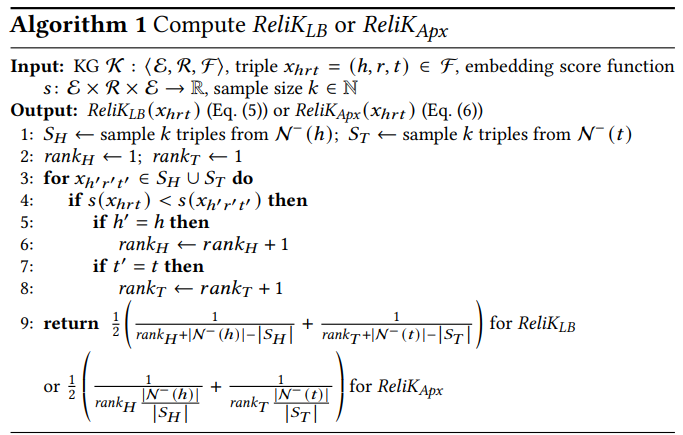

The ReliK function implemented here computes the approximations given by $ReliK_{LB}$ and $ReliK_{Apx}$ as seen in the image above.

To sample from the negative neighbourhoods of a triple's head and tail, I define an ordering of all possible triples with that head and tail respectively, based on the integer indexes assigned to the entities and relations (for example using the `entity_to_id`/ `relation_to_id` attribute of the pykeen `TriplesFactory` object of the trained embedding model, or assigning IDs manually). Then, I remove from that collection of indexes all those corresponding to positive triples. What remains is the negative neighbourhood of the head and tail respectively. Pytorch tensors and vectorization are used to speed up the computation.

For the head, I obtained the indexes as follows (for the tail it is analogous):

Let $E$ be the total number of unique entities and $R$ the total number of unique relations. Given a head $h$, and assuming that a triple can have the same entity for head and tail, there exist $R \cdot E$ triples with head $h$. Each entity and each relation is assigned an integer ID, and these IDs are ordered from 0 to E-1 for the entities, and from 0 to R-1 for the relations. We can define an ordering for all the triples, from $0$ to $R \cdot E - 1$, such that for every index $i$ of a triple $(h, r_i, t_i)$, the following holds:

$$
i = r_i \cdot E + t_i
$$

Where $r_i \in \{0,\cdots,R-1\}$ and $t_i \in \{0,\cdots,E-1\}$ are the relation and tail IDs of the triple with index $i$. To retrieve $r_i$ and $t_i$ from $i$, we can compute:

```
r_i = i // E
t_i = i % E 
```

Once the negative neighbourhoods of head and tail are computed, $k$ samples are drawn from both of them randomly, and the target triple's $rank_H$ (head rank) and $rank_T$ (tail rank) are calculated as the rank of the positive triple with respect to the two neighbourhoods. The function `approximate_relik` returns both $ReliK_{LB}$ and $ReliK_{Apx}$. 

##### Algorithm

In [3]:
# Load pickled PosixPath on Windows (I trained the model on Colab and the file path is incompatible with Windows)
posix_backup = pathlib.PosixPath
pathlib.PosixPath = pathlib.WindowsPath

#  Load the training triples
train_tf = TriplesFactory.from_path_binary('pykeen_results/training_triples')

# Compute number of entities and relations
E = len(train_tf.entity_id_to_label.keys())
R = len(train_tf.relation_id_to_label.keys())
N = R * E

# Number of samples
k = int(0.1 * N) # can be a percentage of the total number of triples

# Compute ReliK scores
triple = [0, 120, 13647]
relik_lb, relik_apx = approximate_relik(triple, train_tf, model, k)

### Combine ReliK + Embedding Scores

The goal of this project is to study how ReliK scores can be used to re-rank or filter candidate triples. 

The problem is: predicting the missing element of an unseen triple (head, relation or tail), given a knowledge graph embedding with associated score function. 

Initially, a triple from the test set is selected, and one of its elements is removed. Then, the trained embedding model is used to produce a ranking of potential candidates for the missing element. Each candidate triple corresponds to a score. Now we want to combine this score with the reliability algorithm.

One approach is to compute the reliability score of the candidate triples, and then, for each of those triples, to calculate the convex combination of the embedding score and the ReliK score. Ideally, the best candidates should have a high rank and high ReliK score. However, if the ReliK score of a triple is low while their rank is high, the combined score might down-rank this triple, taking into account reliability. 

In [33]:
# Create a TriplesFactory object from the test triples, using the same ID mapping as for the entities and relations furing training
# Entities/ relations missing in the mapping but present in the test set are filtered out (the fraction is small)
test_tf = TriplesFactory.from_path(
    'fb15k-237/test.txt',
    entity_to_id=train_tf.entity_to_id,
    relation_to_id=train_tf.relation_to_id,
)

# Store the test triples with IDs in place of strings
test_triples = list(test_tf.mapped_triples)

You're trying to map triples with 30 entities and 0 relations that are not in the training set. These triples will be excluded from the mapping.
In total 28 from 20466 triples were filtered out


In [77]:
def hits_at_k(pred, true_head, k):
    return int(true_head in pred[:k])

In [ ]:
# Parameters
num_candidates = 100 # number of candidates to consider
num_samples = 10000 # k in the ReliK algorithm
num_triples = 10 # can be len(test_triples) or less

# Initialize results dictionaries
predictions_results = dict()
hits_at_1 = dict()
hits_at_3 = dict()
hits_at_10 = dict()

# Iterate over test triples
for triple in tqdm(test_triples[:num_triples]):

    # Get the components
    head = int(triple[0])
    relation = int(triple[1])
    tail = int(triple[2])

    # Set head to None for prediction
    head = None

    # Compute embedding + ReliK scores
    result = compute_scores(model, train_tf, num_candidates, num_samples, head=head, relation=relation, tail=tail, normalization='sigmoid', verbose=False)

    model_scores = result['model_scores']
    relik_scores = result['relik_scores']
    prediction = result['prediction']

    # Combine scores
    lambda_ = 1 # lambda_ = 1 means 100% model score, lambda_ = 0 means 100% ReliK score
    combined = combine_scores(model_scores, relik_scores, lambda_)

    # Add relik and combined score columns to the prediction df
    prediction['relik'] = relik_scores
    prediction['combined'] = combined

    # Save results
    predictions_results[(relation, tail)] = prediction

    # Sort predictions by combined score
    prediction.sort_values(by=['combined'], ascending=False, inplace=True)

    # Evaluate the hits@1, hits@3 and hits@10 of the combined model scores
    # Multiple candidates might be positive, so all candidates should be considered
    pred = list(prediction.filter(like="_id").iloc[:, 0])
    true_head = int(triple[0])

    hits_at_1[(relation, tail)] = hits_at_k(pred, true_head, 1)
    hits_at_3[(relation, tail)] = hits_at_k(pred, true_head, 3)
    hits_at_10[(relation, tail)] = hits_at_k(pred, true_head, 10)

  0%|          | 0/10 [00:00<?, ?it/s]

 50%|█████     | 5/10 [05:25<05:25, 65.09s/it]


KeyboardInterrupt: 

In [ ]:
import pickle

pickle.dump(hits_at_1, open('hits_at_1_model.pkl', 'wb'))
pickle.dump(hits_at_3, open('hits_at_3_model.pkl', 'wb'))
pickle.dump(hits_at_10, open('hits_at_10_model.pkl', 'wb'))
pickle.dump(predictions_results, open('predictions_results_model.pkl', 'wb'))

In [ ]:
hits_at_10

{(131, 4267): 0,
 (126, 5): 1,
 (126, 10): 1,
 (50, 10165): 0,
 (127, 12940): 0,
 (68, 11269): 0,
 (131, 4547): 0}